In [9]:
import rioxarray as rio
from rasterio.enums import Resampling
import xarray as xr
import numpy as np
from scipy.ndimage import gaussian_filter
import settings
import os

sec_per_year = 365.25*24*60*60
chunks=None
vx = rio.open_rasterio(settings.vx_file, band_as_variable=True, masked=True, chunks=chunks).band_1
vy = rio.open_rasterio(settings.vy_file, band_as_variable=True, masked=True, chunks=chunks).band_1
dx = (vx.x[1]-vx.x[0]).values

smoothing =250
vx.data= gaussian_filter(vx.data,smoothing/dx)
vy.data= gaussian_filter(vy.data,smoothing/dx)
saveoutput=True


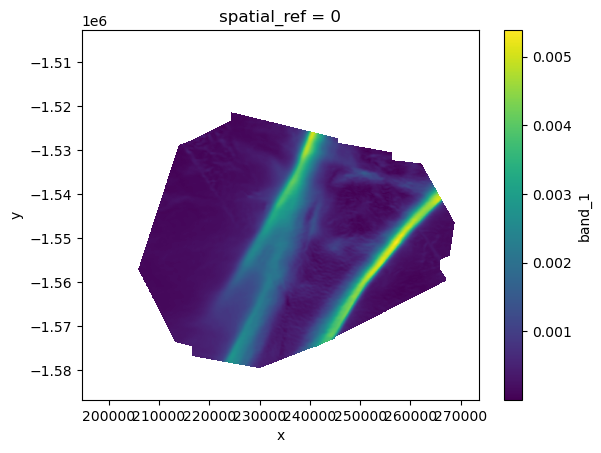

In [10]:
exx = vx.differentiate('x')
dvxdy = vx.differentiate('y')
dvydx = vy.differentiate('x')
eyy = vy.differentiate('y')
exy = 0.5*(dvxdy+dvydx)

ezz = -exx-eyy  
exz = 0
eyz = 0
e_e = np.sqrt(0.5*(exx*exx+eyy*eyy+ezz*ezz+2*(exy**2+exz**2+eyz**2)))
e_e.plot.imshow()


In [11]:
m = (exx+eyy)/2 #mean trace
p = (exx*eyy-exy*exy) #determinant
e1 = m + np.sqrt(m**2 - p)
e2 = m - np.sqrt(m**2 - p)


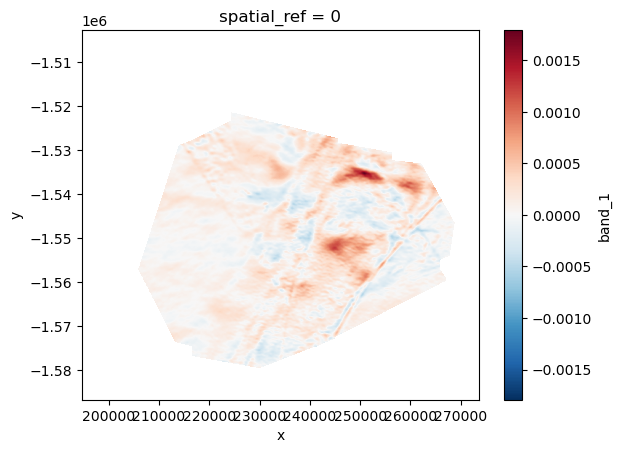

In [12]:

(e1+e2).plot.imshow()

In [13]:
if saveoutput:
    e_e.rio.to_raster(f'{os.path.dirname(settings.vx_file)}/effective_horizontal_strainrate_sm{smoothing:.0f}m.tif', tiled=True, windowed=True, compress='LZW',predictor=3)
    e1.rio.to_raster(f'{os.path.dirname(settings.vx_file)}/horiz_eigen_strainrate1_sm{smoothing:.0f}m.tif', tiled=True, windowed=True, compress='LZW',predictor=3)
    e2.rio.to_raster(f'{os.path.dirname(settings.vx_file)}/horiz_eigen_strainrate2_sm{smoothing:.0f}m.tif', tiled=True, windowed=True, compress='LZW',predictor=3)

